In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

/home/admin1/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [5]:
df = pd.read_csv("spam.csv", encoding='latin-1')

df = df[['v1','v2']]
df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df['label'] = df['label'].map({'ham':0,'spam':1})

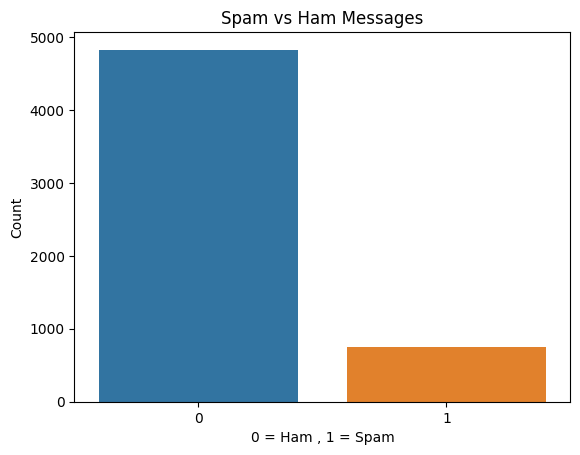

In [9]:
sns.countplot(x=df["label"])
plt.title("Spam vs Ham Messages")
plt.xlabel("0 = Ham , 1 = Spam")
plt.ylabel("Count")
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=42)

In [15]:
vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [19]:
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)


MultinomialNB()

In [21]:
pred_nb = nb.predict(X_test_vec)

In [25]:
lr = LogisticRegression()
lr.fit(X_train_vec, y_train)



LogisticRegression()

In [27]:
pred_lr = lr.predict(X_test_vec)

In [35]:
acc_nb = accuracy_score(y_test, pred_nb)
pre_nb = precision_score(y_test, pred_nb)
rec_nb = recall_score(y_test, pred_nb)

acc_lr = accuracy_score(y_test, pred_lr)
pre_lr = precision_score(y_test, pred_lr)
rec_lr = recall_score(y_test, pred_lr)

In [37]:
acc_nb

0.9668161434977578

In [39]:

acc_lr

0.9524663677130045

In [41]:
pre_nb

1.0

In [43]:
pre_lr

0.970873786407767

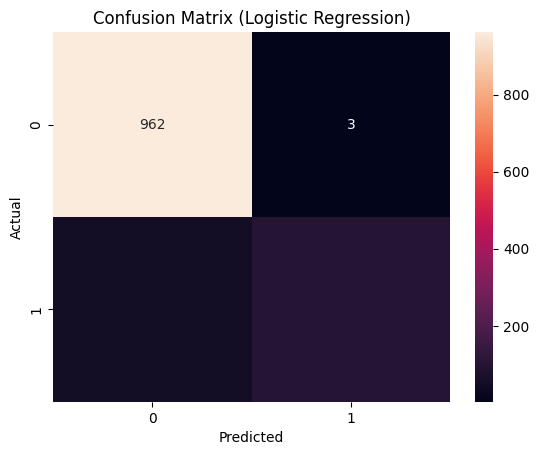

In [31]:
cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

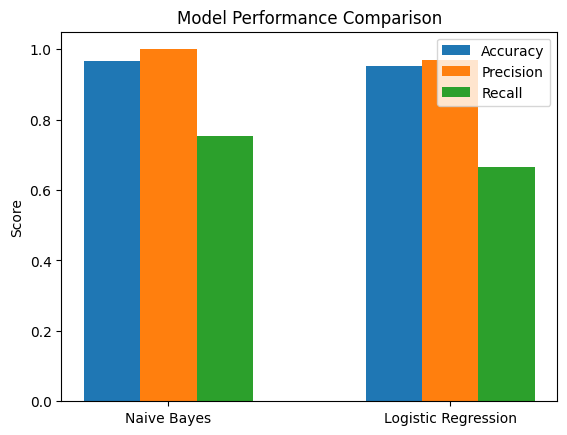

In [33]:
models = ['Naive Bayes', 'Logistic Regression']

accuracy = [acc_nb, acc_lr]
precision = [pre_nb, pre_lr]
recall = [rec_nb, rec_lr]

x = np.arange(len(models))

plt.bar(x-0.2, accuracy, width=0.2, label='Accuracy')
plt.bar(x, precision, width=0.2, label='Precision')
plt.bar(x+0.2, recall, width=0.2, label='Recall')

plt.xticks(x, models)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.legend()

plt.show()